# Dataset Titanic

### Introducción

El hundimiento del Titanic en 1912 es uno de los desastres marítimos más emblemáticos de la historia, con más de 1500 víctimas entre pasajeros y tripulantes. A partir de este trágico evento, se ha generado un conjunto de datos muy conocido que permite analizar qué características influyeron en las probabilidades de supervivencia.

El objetivo de este proyecto es explorar y preprocesar esos datos para construir modelos de clasificación que estimen la probabilidad de que una persona hubiera sobrevivido al naufragio, en función de variables como el género, la edad, la clase social, el número de familiares a bordo, entre otras.

En este notebook se lleva a cabo la limpieza del dataset, el análisis exploratorio y el entrenamiento de diferentes modelos supervisados con el fin de evaluar qué factores fueron más determinantes para la supervivencia y realizar predicciones.

### Descripción de los datos

**Survived:** Indica si el pasajero sobrevivió -> 0 (No sobrevivió) y 1 (Si sobrevivió)

**Pclass:** Clase de pasajero -> primera(1), segunda (2) o tercera (3)

**Name:** Nombre del pasajero

**Sex:** Sexo del pasajero -> Male o Female

**Age:** Edad (en años)

**SibSp:** Cantidad de hermanas/os o esposas/os a bordo

**Parch:** Cantidad de padres o hijos a bordo

**Ticket:** Número de ticket

**Fare:** Tarifa

**Cabin:** Cabina en la cual se encontraba alojado el pasajero

**Embarked:** Puerto de embarque -> C=Cherbourg Q=Queenstown S=Southampton

***

## 1. Carga de datos

#### 1.1. Importación de librerías necesarias

In [284]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib
from pathlib import Path

#### 1.2. Carga del archivo

Se cargan los datos del fichero destinado al entrenamiento de los modelos en un DataFrame, utilizando el Id de los pasajeros como índice de las filas de la tabla.

In [285]:
df = pd.read_csv('../Titanic/titanic.csv', sep=';')

#### 1.3. Vista general del dataset

In [286]:
# Visualización de las primeras filas del dataset
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,"211,3375",B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,"0,9167",1,2,113781,"151,5500",C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,"151,5500",C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,"151,5500",C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,"151,5500",C22 C26,S


In [287]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pclass    1309 non-null   int64 
 1   survived  1309 non-null   int64 
 2   name      1309 non-null   object
 3   sex       1309 non-null   object
 4   age       1046 non-null   object
 5   sibsp     1309 non-null   int64 
 6   parch     1309 non-null   int64 
 7   ticket    1309 non-null   object
 8   fare      1308 non-null   object
 9   cabin     295 non-null    object
 10  embarked  1307 non-null   object
dtypes: int64(4), object(7)
memory usage: 112.6+ KB


In [288]:
# Tamaño del dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 1309 filas y 11 columnas.


## 2. Análisis exploratorio (EDA)

#### 2.1. Distribución de las variables

Se analiza cómo varía la tasa de supervivencia entre hombres y mujeres. Podemos observar que las mujeres muestran una tasa de supervivencia notablemente mayor que los hombres: mientras la mayoría de los hombres no sobrevivió, más del 70 % de las mujeres sí lo hizo.

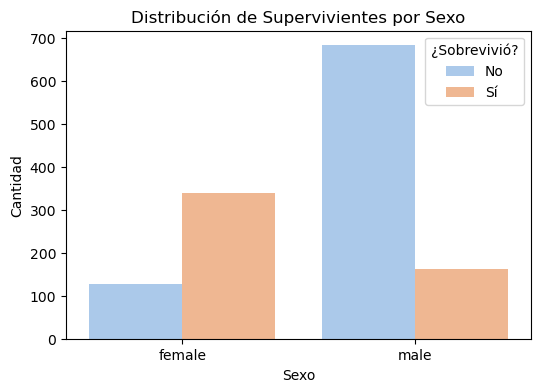

In [289]:
# Distribución de supervivientes por sexo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', hue='survived', palette='pastel')
plt.title('Distribución de Supervivientes por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')
plt.legend(title='¿Sobrevivió?', labels=['No', 'Sí'])
plt.show()

Vemos gráficamente la distribución de la edad de los pasajeros. Podemos observar que la edad media está en torno a los 28 años, el 50 % de los mismos se sitúa entre aproximadamente 20 y 40 años, y existen varios outliers (pasajeros de más de 65 años) que quedan fuera del rango principal.

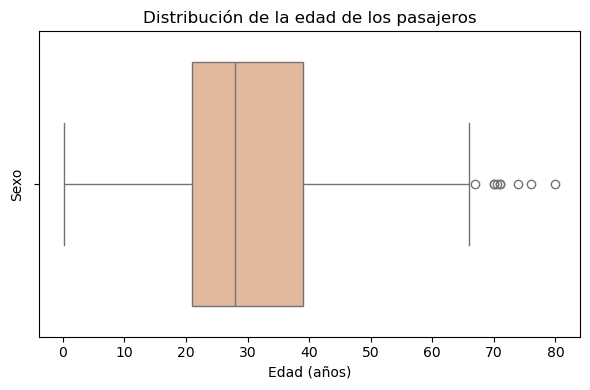

In [290]:
# Transformas variable 'age' a número
df['age'] = df['age'].astype(str).str.replace(',', '.')
df['age'] = df['age'].astype(float)

# Distribución de la variable edad
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='age', color='#efb792')
plt.title('Distribución de la edad de los pasajeros')
plt.xlabel('Edad (años)')
plt.ylabel('Sexo')
plt.tight_layout()
plt.show()


Se analiza también cómo varía la supervivencia según la clase del pasajero ('pclass'), variable que refleja la posición socioeconómica a bordo.

El gráfico muestra que los pasajeros de primera clase tuvieron una mayor tasa de supervivencia, mientras que los de tercera clase presentan un número considerablemente más alto de fallecimientos. Esto sugiere una relación entre clase social y probabilidad de sobrevivir, posiblemente influenciada por el acceso desigual a los botes salvavidas.

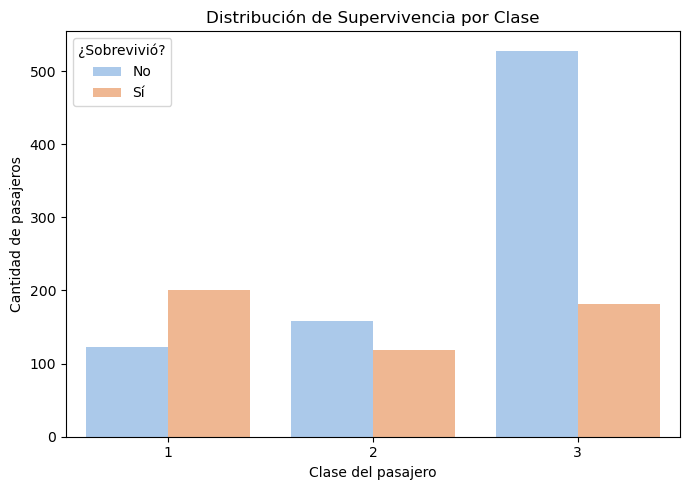

In [291]:
# Distribución de supervivencia por clase
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='pclass', hue='survived', palette='pastel')
plt.title('Distribución de Supervivencia por Clase')
plt.xlabel('Clase del pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.legend(title='¿Sobrevivió?', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

#### 2.2. Correlación entre las variables

Visualizamos la correlación entre las variables más relevantes con el target (Survived). Para esto, primeramente será necesaria la codificación de algunas variables que están como categóricas y son numéricas (como se hizo con 'age'), a fin de poder incorporarla al mapa de correlaciones.

In [292]:
# Transformas variable 'fare' a número
df['fare'] = df['fare'].astype(str).str.replace(',', '.')
df['fare'] = df['fare'].astype(float)

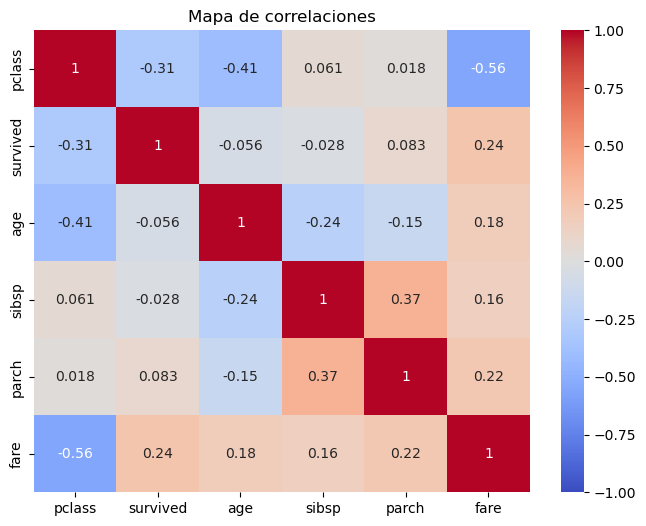

In [293]:
# Correlación de variables con el target
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de correlaciones')
plt.show()

Se pueden ver las siguientes correlaciones:

**Survived vs. Pclass: −0.31**
- Correlación negativa moderada.
- A más alta clase (número 3 = tercera clase) menor probabilidad de supervivencia.

**Survived vs. Fare: +0.24**
- Correlación positiva leve.
- Los pasajeros que pagaron tarifas más altas (clases superiores) tenían algo más de probabilidad de sobrevivir.
  
**Survived vs. Age: -0.056**
- Correlación muy débil.
- La edad por sí sola no explica bien la supervivencia.
  
**Relaciones entre predictores**
- Pclass y Fare tienen una correlación negativa fuerte (-0.56). Los pasajeros de clases más altas pagaron tarifas mucho mayores.
- SibSp y Parch muestran correlación moderada (+0.37), pues familias más grandes tienden a traer ambos tipos de acompañantes.
- Age se relaciona débilmente con Pclass (−0.41): pasajeros de tercera clase suelen ser algo más jóvenes.

## 3. Preprocesamiento de datos

#### 3.1. Borrado de columnas

Se borrará 'name' y 'ticket' por su alta cardinalidad y escaso valor predictivo directo; 'fare' para evitar multicolinealidad con 'pclass'; 'cabin' por la gran cantidad de nulos; y 'embarked' por su baja contribución. Así quedará un dataset más limpio, compacto y enfocado en las variables realmente relevantes para predecir la supervivencia.

In [294]:
df = df.drop(columns=['name', 'ticket', 'fare', 'cabin', 'embarked'])

#### 3.2. Comprobación de valores nulos

Se verifica si existen datos nulos en el dataset y comprobamos que solo hay valores nulos en la variable 'age'. Para mantener la integridad del dataset y evitar pérdida de información, reemplazaré todos los nulos por la media calculada de dicha variable.

In [295]:
# Ver columnas con valores nulos
df.isnull().sum()

pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
dtype: int64

In [296]:
# Reemplazar los nulos con la media
df['age'].fillna(df['age'].mean(), inplace=True)

#### 3.3. Transformación de variables categóricas

In [297]:
# Codificación de la variable 'Sex'
df = pd.get_dummies(data=df, columns=['sex'])
df.head()

,pclass,survived,age,sibsp,parch,sex_female,sex_male
0,1,1,29.0000,0,0,True,False
1,1,1,0.9167,1,2,False,True
2,1,0,2.0000,1,2,True,False
3,1,0,30.0000,1,2,False,True
4,1,0,25.0000,1,2,True,False


## 4. División del dataset

In [298]:
# División entre features (X) y target (y)
X = df.loc[:, df.columns != 'survived'].values
y = df.loc[:, 'survived'].values

# Partición los datos para el entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

## 5. Entrenamiento de modelos 

In [299]:
# ——————————————————————————————
# 1. Regresión logística
lr = LogisticRegression(random_state=0, penalty='l2', solver='lbfgs', max_iter=1000, class_weight={0:1,1:2})
lr.fit(X_train, y_train)

# ——————————————————————————————
# 2. Árbol de decisión
tree = DecisionTreeClassifier(max_depth=5, random_state=0, class_weight={0:1,1:2})
tree.fit(X_train, y_train)

# ——————————————————————————————
# 3. Bosque aleatorio (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=0, class_weight={0:1,1:2})
rf.fit(X_train, y_train)

# ——————————————————————————————
# 4. k-Vecinos más cercanos (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


print("Modelos entrenados correctamente")

Modelos entrenados correctamente


## 6. Comparativa entre los modelos

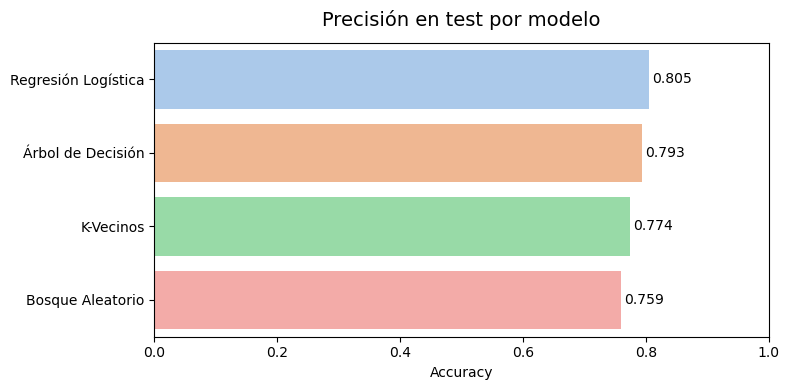

In [300]:
# Calculo de la precisión de test para cada modelo 
metricas = {
    "Regresión Logística": lr.score(X_test, y_test),
    "Bosque Aleatorio":    rf.score(X_test, y_test),
    "Árbol de Decisión":   tree.score(X_test, y_test),
    "K-Vecinos":           knn.score(X_test, y_test)
}

# DataFrame ordenado por desempeño 
resultados = (pd.Series(metricas, name="Accuracy")
                .round(3)          # 3 decimales
                .sort_values(ascending=False)
                .reset_index()
                .rename(columns={"index": "Modelo"}))

# Gráfico de barras con resultados
plt.figure(figsize=(8, 4))
sns.barplot(
    data=resultados,
    x="Accuracy",
    y="Modelo",
    hue="Modelo",
    palette="pastel"
)

# Añadir los valores numéricos al final de cada barra
for i, (acc, modelo) in enumerate(zip(resultados["Accuracy"], resultados["Modelo"])):
    plt.text(acc + 0.005, i, f"{acc:.3f}", va="center", fontsize=10)


plt.title("Precisión en test por modelo", fontsize=14, pad=12)
plt.xlabel("Accuracy")
plt.xlim(0, 1)
plt.ylabel("")
plt.tight_layout()
plt.show()

La Regresión Logística ofrece el mejor desempeño (≈ 0,80 de accuracy), superando ligeramente a los Árboles de decisión (≈ 0,79) y con una ventaja algo mayor sobre Bósques Aleatorios y K-Vecinos. 

## 7. Exportación de los modelos

Por último, se guardan los modelos entrenados utilizando el formato .joblib, un estándar eficiente y liviano para almacenar objetos de aprendizaje automático en Python. Esta exportación permite reutilizar los modelos sin necesidad de volver a entrenarlos cada vez. Los archivos generados serán utilizados en el portfolio web, donde se podrán realizar predicciones en tiempo real. 

In [301]:
# Carpeta de salida
Path("modelos").mkdir(exist_ok=True)

# Guardar cada clasificador
joblib.dump(lr,  "modelos/logistic_regression.joblib")
joblib.dump(tree, "modelos/decision_tree.joblib")
joblib.dump(rf,   "modelos/random_forest.joblib")
joblib.dump(knn,  "modelos/knn.joblib")

print("Modelos exportados a la carpeta 'modelos/'.")

Modelos exportados a la carpeta 'modelos/'.


## Referencias y agradecimientos
**Dataset: Titanic** - Machine Learning from Disaster, disponible en Kaggle
https://www.kaggle.com/c/titanic

**Herramientas utilizadas:**
Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Notas finales:**
Este trabajo fue realizado con fines educativos para practicar el análisis de datos, el entrenamiento de modelos de clasificación y la exportación a producción. Las visualizaciones, modelos y conclusiones tienen carácter exploratorio y académico.